In [1]:
import pandas as pd
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")


In [2]:
# File path
file_path = r"C:\Users\Admin\Desktop\Project\Data\bank_churn_cleaned.csv"

# Load the dataset
df = pd.read_csv(file_path)

In [4]:
from ydata_profiling import ProfileReport

# df já deve existir
profile = ProfileReport(df, title="EDA Report", explorative=True)

output_file = "eda_report.html"
profile.to_file(output_file)

print(f"HTML gerado: {output_file}")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 22/22 [00:00<00:00, 29.55it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

HTML gerado: eda_report.html


In [3]:
df['churn'] = (df['Attrition_Flag'] == 'Attrited Customer').astype(int)

# criar target churn (se ainda não existir)
if "churn" not in df.columns:
    df["churn"] = (df["Attrition_Flag"] == "Attrited Customer").astype(int)


In [4]:
churn_rate = df['churn'].mean()
print(f"Churn rate geral: {churn_rate:.2%}")


Churn rate geral: 16.07%


In [5]:
pd.crosstab(
    df['Card_Category'],
    df['churn'],
    normalize='index'
)[1].sort_values(ascending=False)


Card_Category
Platinum    0.250000
Gold        0.181034
Blue        0.160979
Silver      0.147748
Name: 1, dtype: float64

In [6]:
df['tenure_bin'] = pd.cut(
    df['Months_on_book'],
    bins=[0,12,24,36,48,60,100],
    right=False
)

pd.crosstab(
    df['tenure_bin'],
    df['churn'],
    normalize='index'
)[1]


tenure_bin
[12, 24)    0.142649
[24, 36)    0.150562
[36, 48)    0.167393
[48, 60)    0.168911
Name: 1, dtype: float64

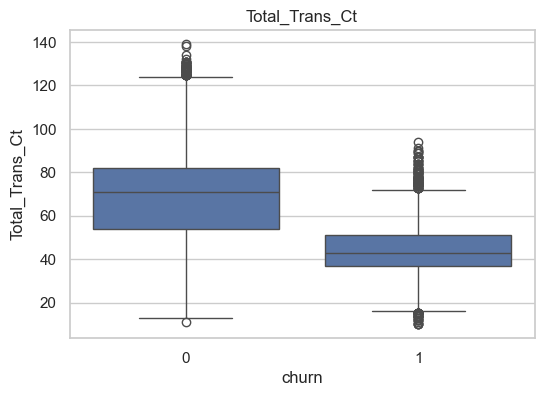

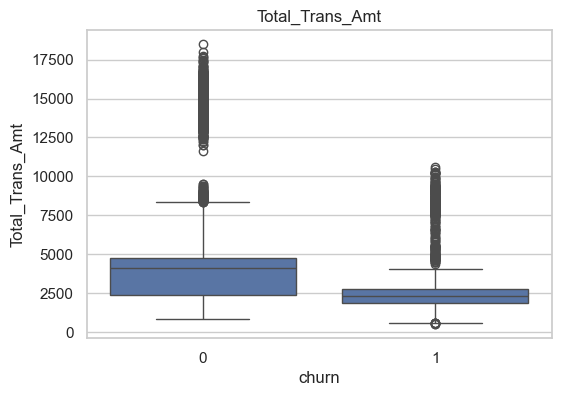

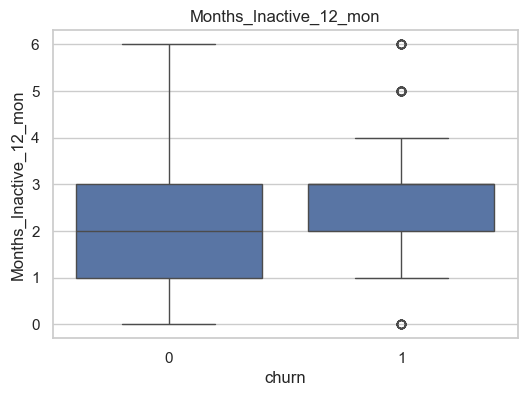

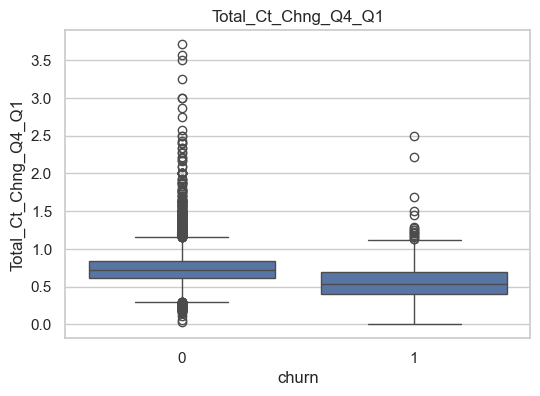

In [7]:
features_deseng = [
    'Total_Trans_Ct',
    'Total_Trans_Amt',
    'Months_Inactive_12_mon',
    'Total_Ct_Chng_Q4_Q1'
]

for col in features_deseng:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='churn', y=col, data=df)
    plt.title(col)
    plt.show()


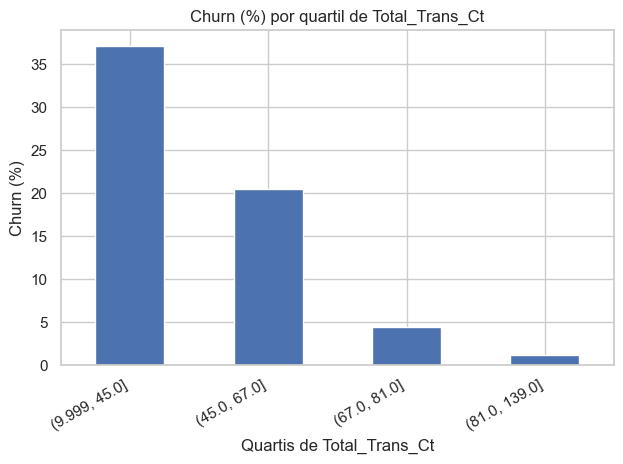

In [8]:

df['trans_ct_q'] = pd.qcut(df['Total_Trans_Ct'], 4)

rate = pd.crosstab(df['trans_ct_q'], df['churn'], normalize='index')[1].sort_index()

ax = (rate * 100).plot(kind="bar")
ax.set_title("Churn (%) por quartil de Total_Trans_Ct")
ax.set_xlabel("Quartis de Total_Trans_Ct")
ax.set_ylabel("Churn (%)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


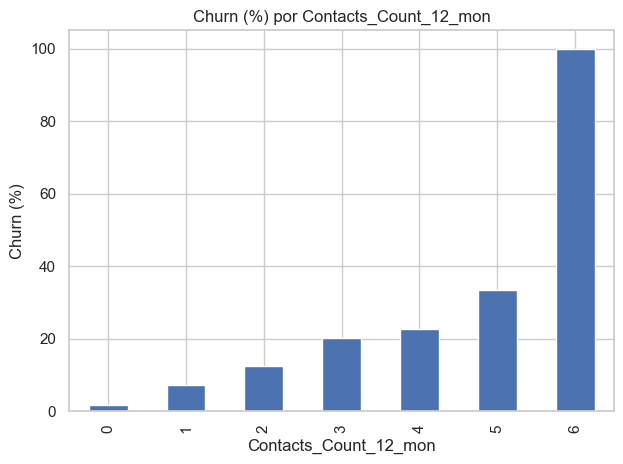

In [9]:
rate = pd.crosstab(df['Contacts_Count_12_mon'], df['churn'], normalize='index')[1].sort_index()

ax = (rate * 100).plot(kind="bar")
ax.set_title("Churn (%) por Contacts_Count_12_mon")
ax.set_xlabel("Contacts_Count_12_mon")
ax.set_ylabel("Churn (%)")
plt.tight_layout()
plt.show()


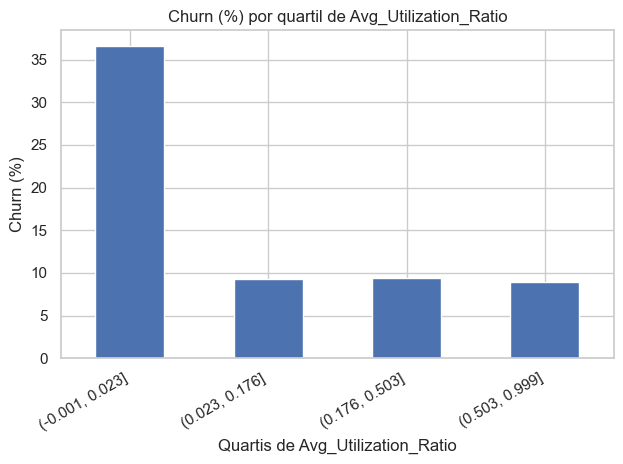

In [10]:
df['util_bin'] = pd.qcut(df['Avg_Utilization_Ratio'], 4)

rate = pd.crosstab(df['util_bin'], df['churn'], normalize='index')[1].sort_index()

ax = (rate * 100).plot(kind="bar")
ax.set_title("Churn (%) por quartil de Avg_Utilization_Ratio")
ax.set_xlabel("Quartis de Avg_Utilization_Ratio")
ax.set_ylabel("Churn (%)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


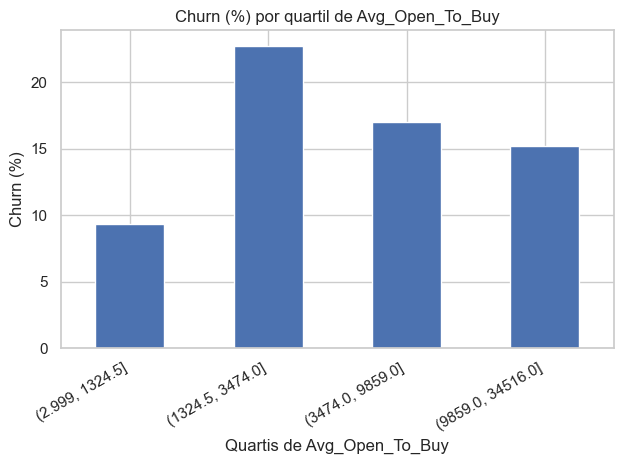

In [11]:
df['open_to_buy_q'] = pd.qcut(df['Avg_Open_To_Buy'], 4)

rate = pd.crosstab(df['open_to_buy_q'], df['churn'], normalize='index')[1].sort_index()

ax = (rate * 100).plot(kind="bar")
ax.set_title("Churn (%) por quartil de Avg_Open_To_Buy")
ax.set_xlabel("Quartis de Avg_Open_To_Buy")
ax.set_ylabel("Churn (%)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


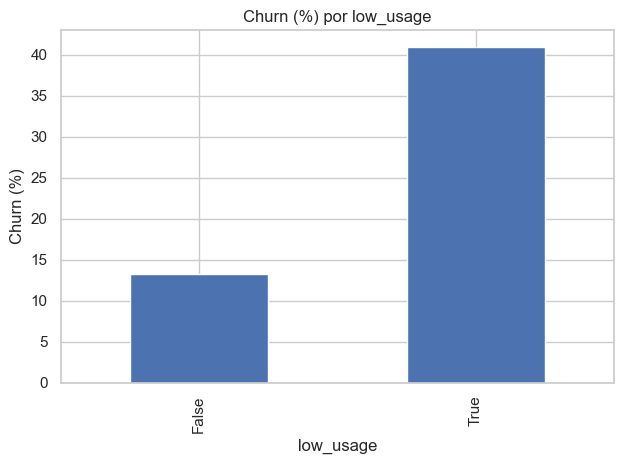

In [12]:
df['low_usage'] = (
    (df['Total_Trans_Ct'] < df['Total_Trans_Ct'].median()) &
    (df['Avg_Utilization_Ratio'] < df['Avg_Utilization_Ratio'].median()) &
    (df['Months_on_book'] > df['Months_on_book'].median())
)

rate = pd.crosstab(df['low_usage'], df['churn'], normalize='index')[1].sort_index()

ax = (rate * 100).plot(kind="bar")
ax.set_title("Churn (%) por low_usage")
ax.set_xlabel("low_usage")
ax.set_ylabel("Churn (%)")
plt.tight_layout()
plt.show()

